In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


# House price prediction using XGBRegressor

**Goal->**
It is your job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable. 

**Metric->**
Submissions are evaluated on Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price. (Taking logs means that errors in predicting expensive houses and cheap houses will affect the result equally.)

#   Loading modules    

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [3]:
train=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv',index_col='Id')
test=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

submit=pd.DataFrame(test['Id'])
test=test.set_index('Id')

# #.Data Visualization

/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:331: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


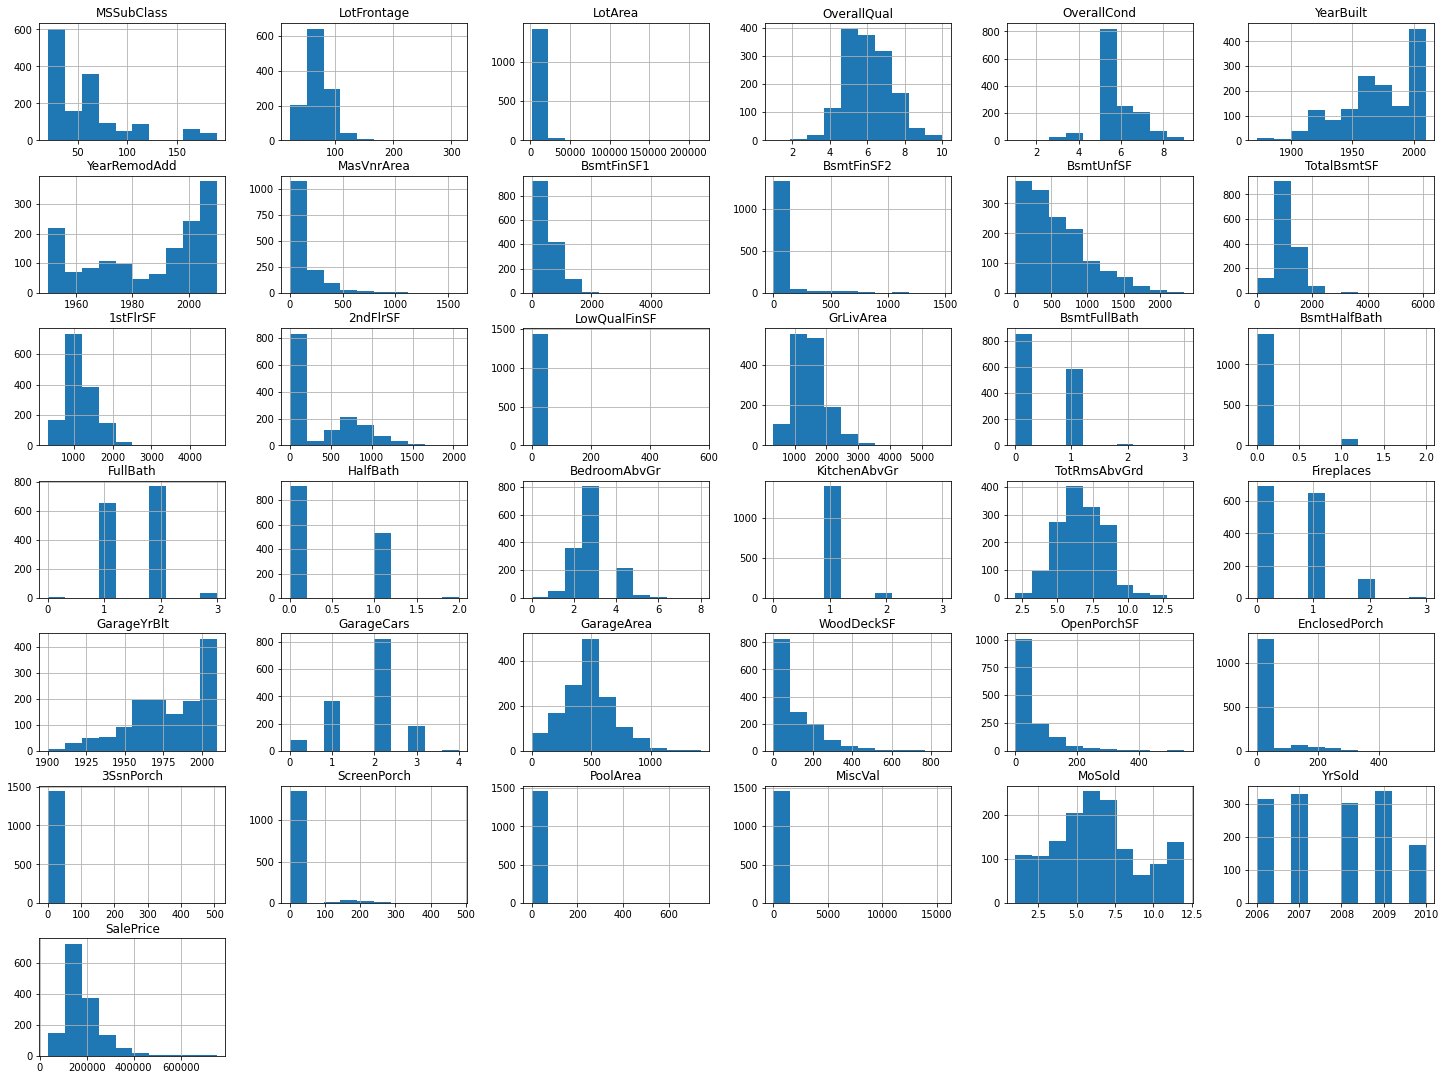

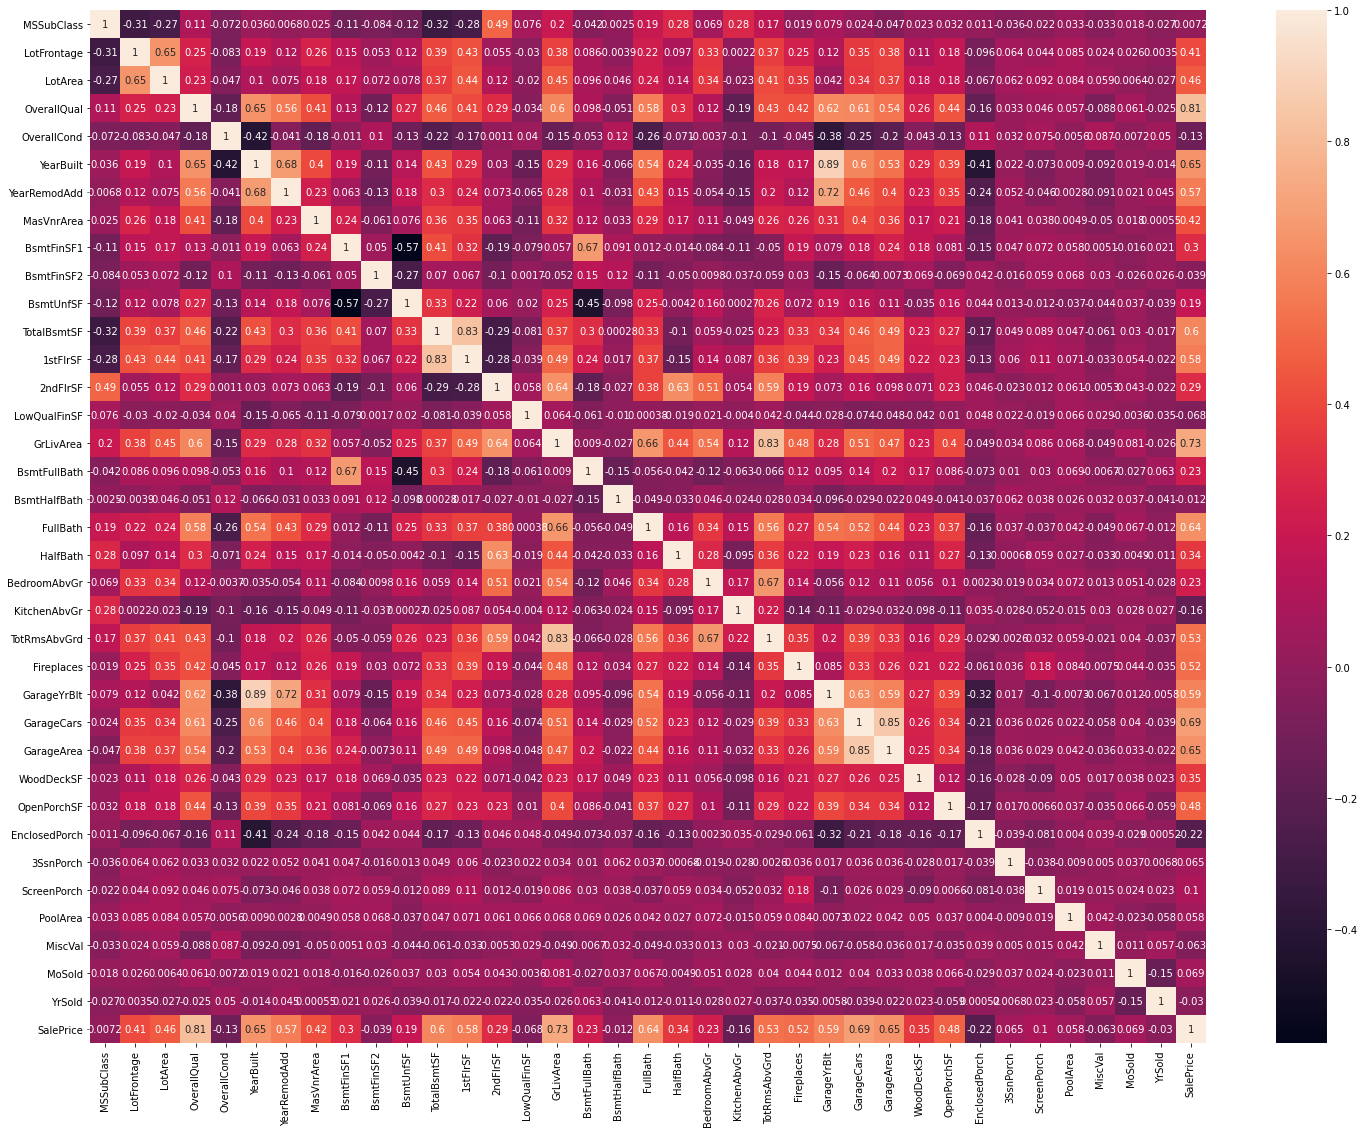

In [4]:
train.select_dtypes(exclude='object').hist(bins=10,figsize=(25,19))
plt.show()


#------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(25,19))
sns.heatmap(train.corr('spearman'),annot=True)
plt.show()

# #.Data Cleaning

In [5]:
#-----------------------------------------------
null=train.loc[:,train.isnull().sum()>500]
train=train.drop(null,axis=1)
test=test.drop(null,axis=1)


#-----------------------------------------------

encode=LabelEncoder()
for i in train.select_dtypes(include='object'):
    train[i]=encode.fit_transform(train[i])
    test[i]=encode.fit_transform(test[i])

# #.Modelling and Prediction

In [6]:
model=XGBRegressor(base_score=0.4, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=0.4603, gamma=0.05,
             gpu_id=-1, importance_type='gain', interaction_constraints='',
             learning_rate=0.05, max_delta_step=0, max_depth=3,
             min_child_weight=1.7817, monotone_constraints='()',
             n_estimators=2200, n_jobs=4, nthread=-1, num_parallel_tree=1,
             random_state=7, reg_alpha=0.464, reg_lambda=0.8571,
             scale_pos_weight=1, subsample=0.5213,silent = True,tree_method='exact',
             validate_parameters=1, verbosity=0)


pipeline=Pipeline(steps=[('impute',IterativeImputer(max_iter=4)),('model',model)])
pipeline.fit(train.drop('SalePrice',axis=1),np.log(train['SalePrice']))

yhat=np.exp(pipeline.predict(test))

submit['SalePrice']=yhat*0.01234+yhat
submit.to_csv('ind.csv',index=False)

/opt/conda/lib/python3.7/site-packages/xgboost/data.py:114: UserWarning: Use subset (sliced data) of np.ndarray is not recommended because it will generate extra copies and increase memory consumption
  "because it will generate extra copies and increase " +


In [7]:

yhat=np.exp(grid_result.predict(test))

submit['SalePrice']=yhat*0.01+yhat
submit.to_csv('ind.csv',index=False)

NameError: name 'grid_result' is not defined